In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import albumentations as A
import requests

from io import BytesIO

from PIL import Image

import random
import torch

from tqdm.notebook import tqdm

import torch.nn as nn

from torch._C import device

import torch.optim as optim

import torch.autograd.grad_mode as grad_mode

from torch.autograd import Function as F

from torch.utils.data import Dataset , DataLoader

import torchvision

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN


from torchvision.models.detection import fasterrcnn_resnet50_fpn


from torchvision.models.detection.rpn import AnchorGenerator

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [3]:
device

device(type='cuda')

In [5]:
def imgshow(number , title=None , size=5):

    root = "/content/dataset/"
    image = cv2.imread(root+"Images/" + str(number) + ".jpeg")

    file = open(root+"Labels/" + str(number) +".txt" , "r")
    txt_data = file.readlines()
    file.close()

    for i in range(0,int(txt_data[0])):
        indices = [int(x) for x in txt_data[i+1].split()]
        start_point = (indices[0] , indices[1])
        end_point = (indices[2] , indices[3])

        cv2.rectangle(image , start_point , end_point , (0,0,255) , 2)

    aspect_ratio = image.shape[0] / image.shape[1]

    plt.figure(figsize=(size+aspect_ratio,size))

    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    plt.title(title+txt_data[0])
    plt.show()

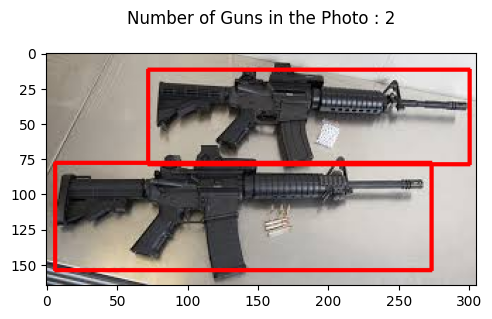

In [6]:
imgshow(119 , title="Number of Guns in the Photo : ")

In [7]:
import os

In [8]:
class Gun_Data(Dataset):

    def __init__(self,root):
        self.image_path = root+"Images/"
        self.labels_path = root+"Labels/"

        self.img_name = [img for img in sorted(os.listdir(self.image_path))]
        self.label_name = [label for label in sorted(os.listdir(self.labels_path))]

    def __getitem__(self,idx):
        image_path =  os.path.join(self.image_path , str(self.img_name[idx]))
        image = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB).astype(np.float32)

        img_res = img_rgb/255
        img_res = torch.as_tensor(img_res).permute(2,0,1)

        label_name  = self.img_name[idx][:-4] + "txt"
        label_path = os.path.join(self.labels_path , str(label_name))

        with open(label_path,"r") as label_file:
            l_count = int(label_file.readline())
            box=[]
            for i in range(l_count):
                box.append(list(map(int,label_file.readline().split())))

        target={}
        area=[]
        labels=[]

        for i in range(len(box)):
            a = (box[i][2] - box[i][0]) * (box[i][3] -  box[i][1])
            area.append(a)

        for i in range(len(box)):
            labels.append(1)

        target["boxes"] = torch.as_tensor(box)
        target["area"] =  torch.as_tensor(area)
        target["image_id"] = torch.as_tensor([idx])
        target["labels"] = torch.as_tensor(labels , dtype=torch.int64)

        img_res = img_res.to(device)
        for key in target:
            if isinstance(target[key] , torch.Tensor):
                target[key] = target[key].to(device)

        return img_res,target

    def __len__(self):
        return len(self.img_name)


In [9]:
class Model:
    def __init__(self,num):
        self.num = num
        self.model = self.create_model()

    def create_model(self):
        model = fasterrcnn_resnet50_fpn(pretrained=True)

        in_features = model.roi_heads.box_predictor.cls_score.in_features

        model.roi_heads.box_predictor = FastRCNNPredictor(in_features , self.num)

        return model

    def compiler(self,optimizer):
        self.optimizer = optimizer

    def train(self,train_data,val_data):
        for epoch in tqdm(range(num_epoch)):
            self.model = self.model.to(device)

            train_loss=0
            self.model.train()

            for img,target in train_data:
                loss_dic = self.model(img,target)
                loss = sum(loss for loss in loss_dic.values())

                self.optimizer.zero_grad()
                loss.backward()

                self.optimizer.step()
                train_loss += loss

            print(f"Epoch : {epoch+1} | Train loss : {train_loss}")

In [10]:
from torch.utils.data import random_split

In [11]:
rcnn = Model(2)

model = rcnn.model

optimizer = optim.Adam(model.parameters() , lr=0.0001)

num_epoch = 50

rcnn.compiler(optimizer)

def collate_fn(batch):
    return tuple(zip(*batch))

dataset = Gun_Data("/content/dataset/")

train_size = int(0.8*len(dataset))
val_size = len(dataset) - train_size

train_dataset , val_dataset = random_split(dataset , [train_size,val_size])

train_loader = DataLoader(train_dataset , batch_size=3 , shuffle=True , num_workers=0 , collate_fn = collate_fn)
val_loader = DataLoader(val_dataset , batch_size=3 , shuffle=False , num_workers=0 , collate_fn = collate_fn)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 196MB/s]


In [12]:
rcnn.train(train_loader , val_loader)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch : 1 | Train loss : 22.986698150634766
Epoch : 2 | Train loss : 17.516481399536133
Epoch : 3 | Train loss : 14.6172513961792
Epoch : 4 | Train loss : 12.439838409423828
Epoch : 5 | Train loss : 11.160600662231445
Epoch : 6 | Train loss : 11.282354354858398
Epoch : 7 | Train loss : 9.374581336975098
Epoch : 8 | Train loss : 8.022110939025879
Epoch : 9 | Train loss : 6.979543685913086
Epoch : 10 | Train loss : 6.47497034072876
Epoch : 11 | Train loss : 5.901728630065918
Epoch : 12 | Train loss : 5.736034393310547
Epoch : 13 | Train loss : 5.286619186401367
Epoch : 14 | Train loss : 5.167668342590332
Epoch : 15 | Train loss : 4.954697132110596
Epoch : 16 | Train loss : 4.61673641204834
Epoch : 17 | Train loss : 4.5399675369262695
Epoch : 18 | Train loss : 4.587370872497559
Epoch : 19 | Train loss : 4.695082187652588
Epoch : 20 | Train loss : 4.524445056915283
Epoch : 21 | Train loss : 4.088603973388672
Epoch : 22 | Train loss : 3.919996500015259
Epoch : 23 | Train loss : 3.7624173164

In [29]:
model_save_path = 'faster_rcnn_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to faster_rcnn_model.pth


In [13]:
def test(data , number=random.randint(1,334)):
    img,target = data[number]
    model.eval()

    predictions = model([img])

    predictions = [{k:v.to(device) for k,v in t.items()} for t in predictions]

    return predictions,target,img

In [14]:
def apply_nms(orig_predictions , iou_threshold=None):

    keep = torchvision.ops.nms(orig_predictions["boxes"],orig_predictions["scores"] , iou_threshold)

    final_predictions = orig_predictions
    final_predictions["boxes"] = final_predictions["boxes"][keep]
    final_predictions["scores"] = final_predictions["scores"][keep]
    final_predictions["labels"] = final_predictions["labels"][keep]

    return final_predictions

In [15]:
def torch_to_pil(img):
    return torchtrans.ToPILImage()(img).convert('RGB')

In [16]:
def plot_img_bbox(img,target,size=5):
    img_cv = cv2.cvtColor(np.array(img) , cv2.COLOR_RGB2BGR)

    for box in target["boxes"]:
        x,y,width,height = box.tolist()
        cv2.rectangle(img_cv , (int(x) , int(y)) , (int(x+width) , int(y+height)) , (0,0,255) ,2)

    aspect_ratio= img_cv.shape[0] / img_cv.shape[1]

    plt.figure(figsize=(size+aspect_ratio , size))
    plt.imshow(cv2.cvtColor(img_cv , cv2.COLOR_BGR2RGB))
    plt.show()

In [23]:
predictions,target , img = test(dataset,number=120)

In [24]:
nms_prediction = apply_nms(predictions[0] , iou_threshold=0.7)

In [25]:
nms_prediction

{'boxes': tensor([[  2.5164, 109.4881,  81.9631, 216.6777],
         [ 97.9987, 111.2222, 177.2274, 215.1423]], device='cuda:0',
        grad_fn=<IndexBackward0>),
 'labels': tensor([1, 1], device='cuda:0'),
 'scores': tensor([0.9987, 0.9981], device='cuda:0', grad_fn=<IndexBackward0>)}

In [26]:
from torchvision import transforms as torchtrans

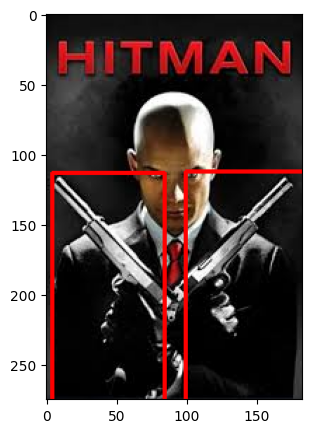

In [27]:
plot_img_bbox(torch_to_pil(img),target)

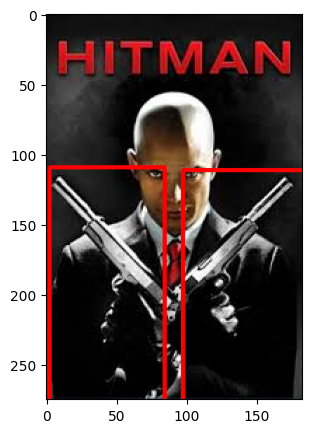

In [28]:
plot_img_bbox(torch_to_pil(img),nms_prediction)

### Load the saved model and perform inference

In [30]:
# Initialize a new model instance with the same architecture
loaded_rcnn = Model(2)
loaded_model = loaded_rcnn.model

# Load the saved state dictionary
model_save_path = 'faster_rcnn_model.pth'
loaded_model.load_state_dict(torch.load(model_save_path))
loaded_model.to(device)

print(f"Model loaded from {model_save_path}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded from faster_rcnn_model.pth


Predictions with loaded model:


{'boxes': tensor([[117.9503, 223.0848, 142.2880, 259.5739],
         [ 13.6844,  14.4938,  57.2359,  56.3065]], device='cuda:0'),
 'labels': tensor([1, 1], device='cuda:0'),
 'scores': tensor([0.9989, 0.9982], device='cuda:0')}

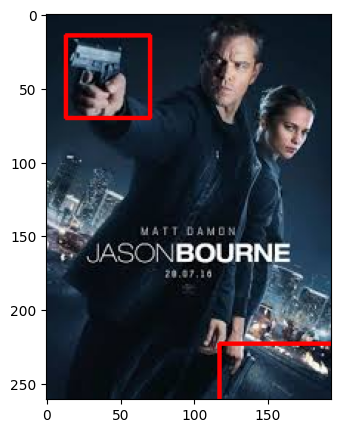

In [31]:
# Set the loaded model to evaluation mode
loaded_model.eval()

# You can now use 'loaded_model' for predictions.
# For example, let's pick another image from the dataset for testing
test_image_index = 100 # Choose a different index for demonstration
img_test, target_test = dataset[test_image_index]

with torch.no_grad():
    loaded_predictions = loaded_model([img_test])

# Apply NMS to the predictions
loaded_nms_prediction = apply_nms(loaded_predictions[0], iou_threshold=0.7)

print("Predictions with loaded model:")
display(loaded_nms_prediction)

# Visualize the predictions
plot_img_bbox(torch_to_pil(img_test), loaded_nms_prediction)